In [3]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

from src.config_presets.tools.get_config import get_config


config = get_config('Daniel/Uncertainty_main')

endpoint_list = config['columns']['labels']

endpoint_list

src/config_presets/Base_config.yaml
src/config_presets/Daniel/Uncertainty_main.yaml


['Dysphagia_M06']

In [28]:
UQ_method_folder_names_dict = {"MC Dropout" :  "Data MC Dropout PRIMA no Aug", 
                               "Deep Ensemble" : "Data Deep Ensemble PRIMA",
                               "TTA" : "Data TTA",
                               
                               }

endpoint_folders_dict = { "Dysphagia_M06" : "Dysphagia_M06",
                         # 'Xerostomia_M06' : 'Xerostomia_M06',
                         
                         #"OS_2year_censored" : "OS",
                         # "LRC_2year_censored" : "LRC"
                         }




number_of_iterations = 5
ALL_DFS_DICT = {}

for endpoint_name, endpoint_folder_name in endpoint_folders_dict.items():
    ALL_DFS_DICT[endpoint_name] = {}

    for UQ_method_name, UQ_method_folder in UQ_method_folder_names_dict.items():
        ALL_DFS_DICT[endpoint_name][UQ_method_name] = {}

        for iteration_n in range(1, number_of_iterations+1):
            ALL_DFS_DICT[endpoint_name][UQ_method_name][iteration_n] = {}

            # list all N_patients folders
            root_dir = os.path.join("/home/macraedc/UQ_results/", UQ_method_folder, endpoint_folder_name + f"_run_{iteration_n}")

            print(root_dir)

            n_patients_folders = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]

            for n_patients_folder in n_patients_folders:
                n_patients = n_patients_folder.split("_")[-1]
                
                if UQ_method_name == "Deep Ensemble":
                    all_preds_csv_dir = os.path.join(root_dir, n_patients_folder, "all_predictions.csv")
                else:
                    all_preds_csv_dir = os.path.join(root_dir, n_patients_folder, "model_1", "all_predictions.csv")

                if not os.path.exists(all_preds_csv_dir):
                    print(f"File not found: {all_preds_csv_dir}")
                else:
                    all_preds_df = pd.read_csv(all_preds_csv_dir, sep=';')

                    ALL_DFS_DICT[endpoint_name][UQ_method_name][iteration_n][n_patients] = all_preds_df


def reorder_nested_dict(original_dict):
    reordered = {}
    for a_key, b_dict in original_dict.items():
        for b_key, c_dict in b_dict.items():
            for c_key, value in c_dict.items():
                # Create the new structure: A -> C -> B
                reordered.setdefault(a_key, {}).setdefault(c_key, {})[b_key] = value
    return reordered

#ALL_DFS_DICT = reorder_nested_dict(ALL_DFS_DICT)
# Example usage:
# original_dict = {'A1': {'B1': {'C1': 1, 'C2': 2}, 'B2': {'C1': 3}}}
# new_dict = reorder_nested_dict(original_dict)

/home/macraedc/UQ_results/Data MC Dropout PRIMA no Aug/Dysphagia_M06_run_1
/home/macraedc/UQ_results/Data MC Dropout PRIMA no Aug/Dysphagia_M06_run_2
/home/macraedc/UQ_results/Data MC Dropout PRIMA no Aug/Dysphagia_M06_run_3
/home/macraedc/UQ_results/Data MC Dropout PRIMA no Aug/Dysphagia_M06_run_4
/home/macraedc/UQ_results/Data MC Dropout PRIMA no Aug/Dysphagia_M06_run_5
/home/macraedc/UQ_results/Data Deep Ensemble PRIMA/Dysphagia_M06_run_1
/home/macraedc/UQ_results/Data Deep Ensemble PRIMA/Dysphagia_M06_run_2
/home/macraedc/UQ_results/Data Deep Ensemble PRIMA/Dysphagia_M06_run_3
/home/macraedc/UQ_results/Data Deep Ensemble PRIMA/Dysphagia_M06_run_4
/home/macraedc/UQ_results/Data Deep Ensemble PRIMA/Dysphagia_M06_run_5
/home/macraedc/UQ_results/Data TTA/Dysphagia_M06_run_1
/home/macraedc/UQ_results/Data TTA/Dysphagia_M06_run_2
/home/macraedc/UQ_results/Data TTA/Dysphagia_M06_run_3
/home/macraedc/UQ_results/Data TTA/Dysphagia_M06_run_4
/home/macraedc/UQ_results/Data TTA/Dysphagia_M06_r

In [29]:
%load_ext autoreload
%autoreload 2

from src.uncertainty.metrics.mutual_information import mutual_information
from src.uncertainty.metrics.entropy import binary_entropy
from src.uncertainty.metrics.variance import variance

def compute_uncertainty_metrics_for_endpoint(df, endpoint):
#for endpoint in endpoint_list:
    df_UQ_results = pd.DataFrame(index=df.index)

    #label_columns = [x + '_true' for x in endpoint_list]
    endpoint_pred_columns = [col for col in df.columns if 'pred' in col]

    all_endpoint_preds = df[endpoint_pred_columns]
    #all_endpoint_preds = (all_endpoint_preds - all_endpoint_preds.min().min()) / (all_endpoint_preds.max().max() - all_endpoint_preds.min().min())
    mean_endpoint_preds = all_endpoint_preds.mean(axis=1)


    df_UQ_results['Mean Prediction'] = mean_endpoint_preds
    
    df_UQ_results['True Labels'] = df[endpoint + '_true']
        
    df_UQ_results['Mutual Information'] = mutual_information(all_endpoint_preds)
    df_UQ_results['Binary Entropy'] = binary_entropy(mean_endpoint_preds)
    df_UQ_results['Variance'] =  variance(all_endpoint_preds)
    df_UQ_results['IQR'] = all_endpoint_preds.quantile(0.75, axis=1) - all_endpoint_preds.quantile(0.25, axis=1)

    return df_UQ_results


UQ_RESULTS_DICT = {}


#  ALL_DFS_DICT[endpoint_folder][UQ_method_folder][n_patients]

for endpoint, dfs in ALL_DFS_DICT.items():
    UQ_RESULTS_DICT[endpoint] = {}

    for method, method_dfs in dfs.items():
        UQ_RESULTS_DICT[endpoint][method] = {}

        for iteration_n in range(1, number_of_iterations+1):
            UQ_RESULTS_DICT[endpoint][method][iteration_n] = {}

            iteration_dfs = method_dfs[iteration_n]

            for amount, df_all_preds in iteration_dfs.items():
                # label_columns = [x + '_true' for x in endpoint_list]
                # pred_columns = [col for col in dfs.columns if 'pred' in col]

                df_UQ_results = compute_uncertainty_metrics_for_endpoint(df_all_preds, endpoint)
                UQ_RESULTS_DICT[endpoint][method][iteration_n][amount] = df_UQ_results


#UQ_methods_list = list(ALL_DFS_DICT["Dysphagia_M06"].keys()) 
#UQ_metrics_list = ["Binary Entropy", "Variance", "Mutual Information"]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
UQ_RESULTS_DICT["Dysphagia_M06"]['MC Dropout'][1]

{'100':      Mean Prediction  True Labels  Mutual Information  Binary Entropy  \
 0           0.009987          0.0            0.015070        0.080704   
 1           0.262263          1.0            0.014634        0.830141   
 2           0.007919          0.0            0.005837        0.066656   
 3           0.008521          0.0            0.009712        0.070819   
 4           0.210708          0.0            0.010248        0.742833   
 ..               ...          ...                 ...             ...   
 236         0.128308          1.0            0.010284        0.552779   
 237         0.029655          0.0            0.008014        0.192658   
 238         0.000502          0.0            0.000562        0.006225   
 239         0.001821          0.0            0.003387        0.019201   
 240         0.006218          0.0            0.007343        0.054520   
 
          Variance       IQR  
 0    4.067792e-04  0.007970  
 1    4.149213e-03  0.063127  
 2    6.83

In [31]:
UQ_methods_list = list(UQ_RESULTS_DICT["Dysphagia_M06"].keys())  + ["Dee"]
UQ_metrics_list = ["Binary Entropy", "Variance", "Mutual Information"]
UQ_metrics_list = ["Variance", "Mutual Information"]


ENDPOINT_TYPES = {
    "Xerostomia_M06": "Binary",
    "Dysphagia_M06": "Binary",
    "OS_2year_censored": "Binary",
    "LRC_2year_censored": "Binary"
    #"OS_2year_no_clinical": "Binary"
}

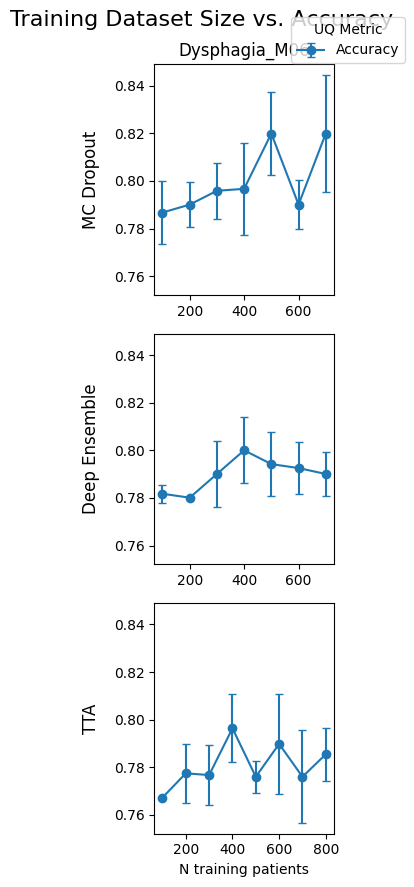

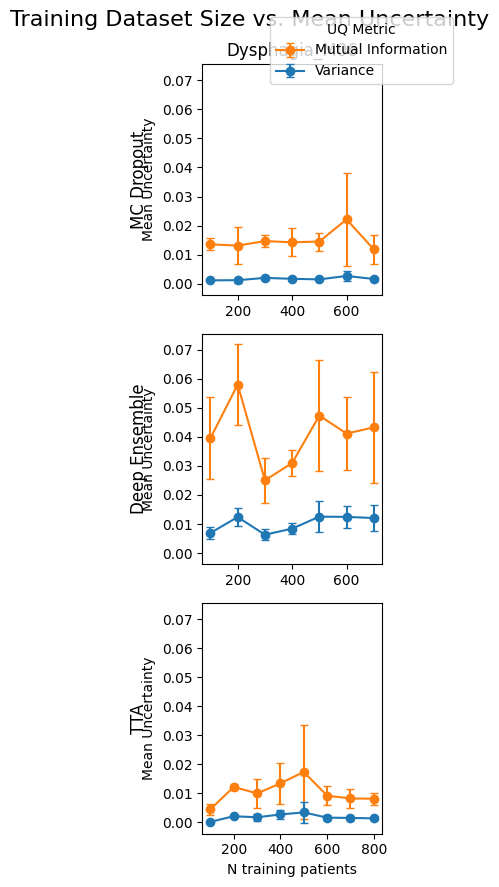

In [32]:
from src.uncertainty.visualisation.plotting_UQ import plot_nested_UQ


UQ_methods_list = ['MC Dropout', 'Deep Ensemble', 'TTA'] #, 'Deep Ensemble']

fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="plot_accuracy_over_dataset_size", 
                     row_key="method", col_key="endpoint", N_bins=5, normalisation_method=None)
plt.show()
# plot_UQ_values_over_dataset_size


fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="plot_UQ_values_over_dataset_size", 
                     row_key="method", col_key="endpoint", N_bins=5, normalisation_method=None)
plt.show()

# fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="sparsification", row_key="endpoint", col_key="method")
# plt.show()
